In [239]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.tri as tri
import glob

eps = 0.001

In [240]:
import numpy as np

time, K, a1, a3, excess_mass, xCMm, yCMm = np.loadtxt(
    "obs_eps="+str(eps)+".txt",
    skiprows=1,
    unpack=True
)

# Driving is activated at time t0 smoothly in a time small compared to t_activation
t0 = 1e3
t_activation = 10

# Measure the observable on the stationary state
t_target = t0 - t_activation
idx = np.where(time <= t_target)[0]
if len(idx) == 0:
    raise ValueError("No time satisfies the condition")
i_last = idx[-1]   # last valid index
a1 = a1[i_last]
a3 = a3[i_last]   # assuming you meant a3 (not a2)
m = excess_mass[i_last]
K = K[i_last]

# Consider only the time after turning on the driving
mask = time > t0
time = time[mask]
xCM = xCMm[mask]/excess_mass[mask]    # vCMxm is the integral of x*hhat so you still need to divide by the excess mass!
yCM = yCMm[mask]/excess_mass[mask]

In [241]:
ha = 0.5
def dwetting_pot(h):
     return (- ha**3*h**(-6) + h**(-3))

<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_31696/3253223141.py:18: SyntaxWarning: invalid escape sequence '\e'
  plt.title('$\epsilon = $'+str(eps))


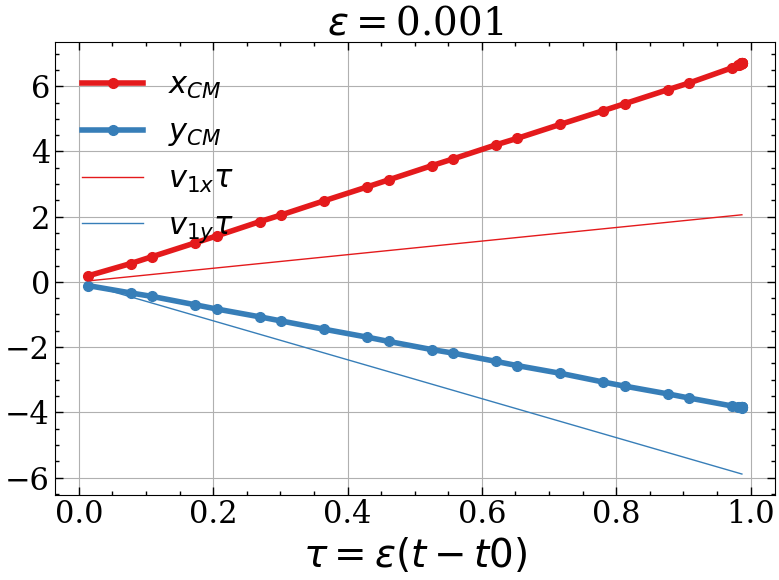

In [ ]:
# Theory
eta = 1
prefactor = 1/(3*eta*K) # eta is mu in 2DThinfilm.py
v1x = prefactor*(m-a3)
v1y = prefactor*(dwetting_pot(ha)*a3-a1)  # TODO: Measure hout  


# Experiment
tau = (time-t0)*eps    # Changing eps, the displacement is slower
lx, = plt.plot(tau,xCM,'.-',label='$x_{CM}$')
ly, = plt.plot(tau,yCM,'.-',label='$y_{CM}$')
# Theory
plt.plot(tau, v1x*tau,color=lx.get_color(),lw=1,label='$v_{1x} \\tau$')
plt.plot(tau, v1y*tau,color=ly.get_color(),lw=1,label='$v_{1y}\\tau$')


plt.xlabel('$\\tau=\\epsilon(t-t0)$')
plt.title('$\epsilon = $'+str(eps))
plt.grid()
plt.legend()


In [245]:
dwetting_pot(0.51)

0.4348076188868202